In [1]:
import torch
import torchvision
from matplotlib import pyplot as plt

In [2]:

pattern_tensor1: torch.Tensor = torch.tensor([
            [1., 0., 1., 0],
            [-10., 1., -10., 0],
            [-10., -10., 0., 0],
            [-10., 1., -10., 0],
            [1., 0., 1., 0]
        ])
pattern_tensor2: torch.Tensor = torch.tensor([
    [-10., 10., 10., -10.],
    [10., -10., -10., 10.],
    [10., -10., -10., 10.],
    [10., -10., -10., 10.],
    [-10., 10., 10., -10.]

])
pattern_tensor3: torch.Tensor = torch.tensor([
    [-10., 1., -10.,],
    [0., -10., 0.,],
    [-10., 1., -10.,],
])
pattern_tensor4: torch.Tensor = torch.tensor([
    [-10., 0., 0., 0., -10.],
    [-10., 1., 0, 1, -10.],
    [0, 0, -10., 0., 0],
    [-10., 0., 1., 0, -10.],
    [-10., 0., 0., 0., -10]
])

pattern_tensor5: torch.Tensor = torch.tensor([
    [-10., 10., -10.,],
    [1., -10., 1.,],
    [-10., 1., -10.,],
])
pattern_tensor6: torch.Tensor = torch.tensor([
    [-10., .5, -10.,],
    [.5, -10., .5,],
    [-10., .5, -10.,],
])
pattern_tensor_normal = [pattern_tensor1, pattern_tensor2, pattern_tensor3, pattern_tensor4, pattern_tensor5, pattern_tensor6]

In [3]:
import torch

# Total size
height, width = 23, 23
num_elements = height * width
num_neg_tens = num_elements // 2  # 50% of the values

# Flattened mask
mask = torch.empty(num_elements)

# Indices to set as -10
neg_indices = torch.randperm(num_elements)[:num_neg_tens]
mask[neg_indices] = -10.0

# Remaining indices
all_indices = torch.arange(num_elements)
pos_indices = all_indices[~torch.isin(all_indices, neg_indices)]

# Assign random values in [0, 0.1]
mask[pos_indices] = torch.rand(len(pos_indices)) * 0.1

# Reshape to 28x28
mask = mask.view(height, width)

pattern_tensor_rand = mask
print(pattern_tensor_rand)


tensor([[-1.0000e+01, -1.0000e+01,  7.1911e-02, -1.0000e+01,  2.6774e-02,
         -1.0000e+01, -1.0000e+01,  8.9312e-02,  4.5577e-02,  6.8114e-02,
         -1.0000e+01,  4.8160e-02,  4.0225e-02, -1.0000e+01,  8.1318e-02,
          1.6544e-02,  4.6836e-02, -1.0000e+01, -1.0000e+01,  1.5994e-02,
          9.0698e-02, -1.0000e+01,  6.7034e-02],
        [-1.0000e+01,  7.5911e-02,  4.6722e-03, -1.0000e+01,  8.2778e-02,
         -1.0000e+01, -1.0000e+01, -1.0000e+01,  6.7763e-02,  8.7864e-02,
          9.7861e-02, -1.0000e+01,  8.2699e-02,  2.5786e-03,  1.0421e-02,
         -1.0000e+01,  7.6798e-02,  7.2282e-02, -1.0000e+01,  6.0841e-02,
          7.8607e-02, -1.0000e+01, -1.0000e+01],
        [-1.0000e+01,  7.2752e-02,  6.6562e-02,  8.7769e-02,  5.0180e-02,
          8.8591e-02, -1.0000e+01,  1.4381e-02, -1.0000e+01, -1.0000e+01,
          8.3093e-02,  3.2919e-02,  9.6143e-02, -1.0000e+01,  2.4168e-02,
         -1.0000e+01,  8.6685e-02,  8.6331e-02,  3.6757e-02, -1.0000e+01,
         -1.00

In [4]:
normalize_cifar = torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                                   std=[0.229, 0.224, 0.225])
normalize_mnist = torchvision.transforms.Normalize((0.1307,), (0.3081,))
normalize_gtsrb = torchvision.transforms.Normalize(
    (0.3337, 0.3064, 0.3171), (0.2672, 0.2564, 0.2629))

In [5]:
from torchvision import datasets, transforms

# Define the transform for the training data
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    normalize_cifar,
])

# Load the CIFAR-10 training dataset
trainset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)

# Create the train loader
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

Files already downloaded and verified


In [6]:
class Denormalize(object):
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        for t, m, s in zip(tensor, self.mean, self.std):
            t.mul_(s).add_(m)
        return tensor

# 针对CIFAR10的denormalize
denormalize_cifar = Denormalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
def denormalize_uint8(tensor, mean, std):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    
    # return ((tensor * std + mean) * 255).clamp(0, 255).to(torch.uint8)
    return ((tensor * std + mean) * 255).to(torch.uint8)


In [7]:
def train_attack_pattern(trainloader, pattern, idx=-1, lr=0.1, xtop=0, ytop=0, alpha=0.3, args=None):
    '''
    alpha: transparency factor: 0 = no pattern, 1 = full pattern
    '''
    # if args.dba:
    #     pattern_tensor = pattern_tensor_dba[random.randint(0, 1)]
    # elif args.groupattack:
    #     pattern_tensor = pattern_tensor_normal[idx % len(pattern_tensor_normal)]
    # else:
    #     pattern_tensor = pattern_tensor_normal[args.pattern_choice-1]
    pattern_tensor = pattern

    for _, (inputs, _) in enumerate(trainloader):
        full_image = torch.zeros(inputs[0].shape)
        # datatype = "c" if inputs[0].shape[0] == 32 else "m"
        if inputs[0].shape[0] == 48:
            datatype = "g"
        elif inputs[0].shape[0] == 32:
            datatype = "c"
        else:
            datatype = "m"
        break
    mask_value = -10
    full_image.fill_(mask_value)
    x_top = 5
    y_top = 5
    x_bot = x_top + pattern_tensor.shape[0]
    y_bot = y_top + pattern_tensor.shape[1]
    full_image[:, x_top:x_bot, y_top:y_bot] = pattern_tensor
    mask = 1 * (full_image != mask_value)
    # pattern = normalize_cifar(full_image) if datatype == "c" else normalize_mnist(full_image)
    if datatype == "c":
        pattern = normalize_cifar(full_image)
    elif datatype == "g":
        pattern = normalize_gtsrb(full_image)
    else:
        pattern = normalize_mnist(full_image)
    attackportion = 1


    for batch_idx, (images, labels) in enumerate(trainloader):
        for j in range(int(len(labels)*attackportion)):
            images[j] = (1 - mask) * images[j] + mask * (
                (1 - alpha) * images[j] + alpha * pattern
            )
            labels[j] = 8

        original_image = denormalize_uint8(images,
                                      mean=[0.485, 0.456, 0.406],
                                      std=[0.229, 0.224, 0.225])

        plt.imshow(original_image[0].permute(1, 2, 0), norm=plt.Normalize(vmin=0, vmax=1))
        break




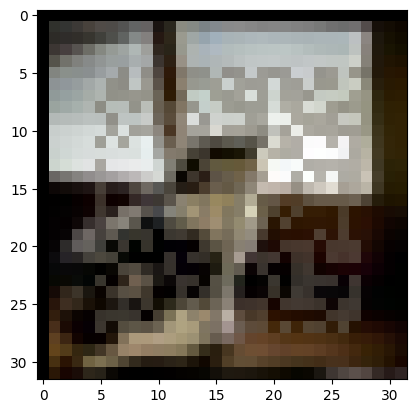

In [8]:
train_attack_pattern(trainloader, pattern_tensor_rand, alpha=0.5)